In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

folder_path = "/content/drive/MyDrive/cleaned_dataset/data"

files = sorted(os.listdir(folder_path))

print("Total files:", len(files))
print("First 5 files:", files[:5])

Total files: 7565
First 5 files: ['00001.csv', '00002.csv', '00003.csv', '00004.csv', '00005.csv']


In [ ]:
# Print actual folder content
print("Checking folder path...\n")

for i, f in enumerate(files[:20]):
    print(i, f)

Checking folder path...

0 00001.csv
1 00002.csv
2 00003.csv
3 00004.csv
4 00005.csv
5 00006.csv
6 00007.csv
7 00008.csv
8 00009.csv
9 00010.csv
10 00011.csv
11 00012.csv
12 00013.csv
13 00014.csv
14 00015.csv
15 00016.csv
16 00017.csv
17 00018.csv
18 00019.csv
19 00020.csv


In [ ]:
print("\nTrying full path of first file:")
print(os.path.join(folder_path, files[0]))


Trying full path of first file:
/content/drive/MyDrive/cleaned_dataset/data/00001.csv


In [ ]:
!ls "/content/drive/MyDrive/cleaned_dataset/data" | head

00001.csv
00002.csv
00003.csv
00004.csv
00005.csv
00006.csv
00007.csv
00008.csv
00009.csv
00010.csv


In [ ]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/cleaned_dataset/data/00001.csv")

df.head()

,Voltage_measured,Current_measured,Temperature_measured,Current_load,Voltage_load,Time
0,4.246711,0.000252,6.212696,0.0002,0.000,0.000
1,4.246764,-0.001411,6.234019,0.0002,4.262,9.360
2,4.039277,-0.995093,6.250255,1.0000,3.465,23.281
3,4.019506,-0.996731,6.302176,1.0000,3.451,36.406
4,4.004763,-0.992845,6.361645,1.0000,3.438,49.625


In [ ]:
# Clean the data properly

df_clean = df.copy()

# Remove NaN values
df_clean = df_clean.dropna()

# Sort by Time (VERY IMPORTANT)
df_clean = df_clean.sort_values(by="Time")

# Reset index
df_clean = df_clean.reset_index(drop=True)

print("Cleaned shape:", df_clean.shape)
df_clean.head()

Cleaned shape: (490, 6)


,Voltage_measured,Current_measured,Temperature_measured,Current_load,Voltage_load,Time
0,4.246711,0.000252,6.212696,0.0002,0.000,0.000
1,4.246764,-0.001411,6.234019,0.0002,4.262,9.360
2,4.039277,-0.995093,6.250255,1.0000,3.465,23.281
3,4.019506,-0.996731,6.302176,1.0000,3.451,36.406
4,4.004763,-0.992845,6.361645,1.0000,3.438,49.625


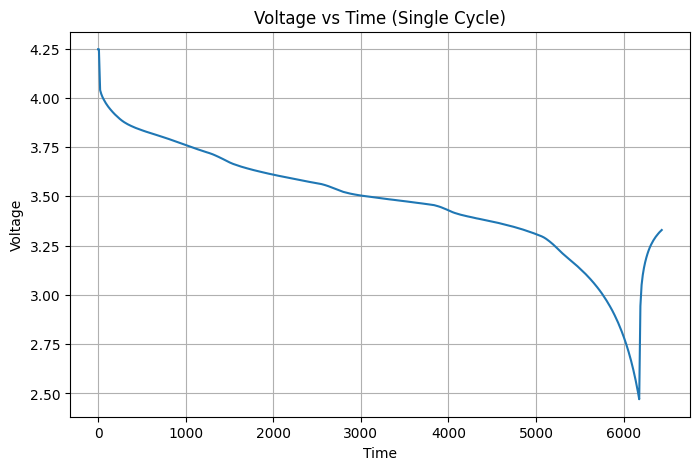

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(df_clean["Time"], df_clean["Voltage_measured"])

plt.xlabel("Time")
plt.ylabel("Voltage")
plt.title("Voltage vs Time (Single Cycle)")
plt.grid()

plt.show()

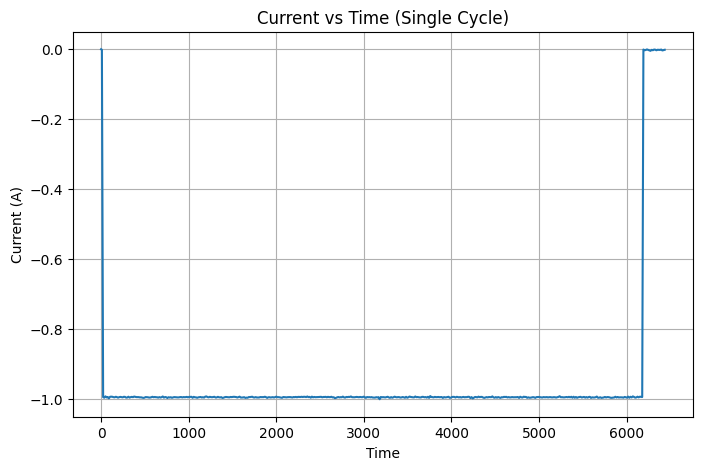

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(df_clean["Time"], df_clean["Current_measured"])

plt.xlabel("Time")
plt.ylabel("Current (A)")
plt.title("Current vs Time (Single Cycle)")
plt.grid()

plt.show()

In [ ]:
import numpy as np

# Extract values
V = df_clean["Voltage_measured"].values
I = df_clean["Current_measured"].values
t = df_clean["Time"].values

# Compute time difference
dt = np.diff(t, prepend=t[0])

# Energy calculation
energy = np.sum(V * I * dt)

# Take absolute value (energy delivered)
energy = abs(energy)

print("Energy of this cycle:", energy, "Joules")

Energy of this cycle: 21378.096141203503 Joules


In [ ]:
energy_list = []

for file in files[:100]:   # start with 100 files (safe)
    try:
        df = pd.read_csv(os.path.join(folder_path, file))

        # Check if it's cycle data
        if "Voltage_measured" in df.columns:

            df = df.dropna().sort_values(by="Time")

            V = df["Voltage_measured"].values
            I = df["Current_measured"].values
            t = df["Time"].values

            dt = np.diff(t, prepend=t[0])

            energy = np.sum(V * I * dt)
            energy_list.append(abs(energy))

    except:
        continue

print("Total valid cycles:", len(energy_list))

Total valid cycles: 78


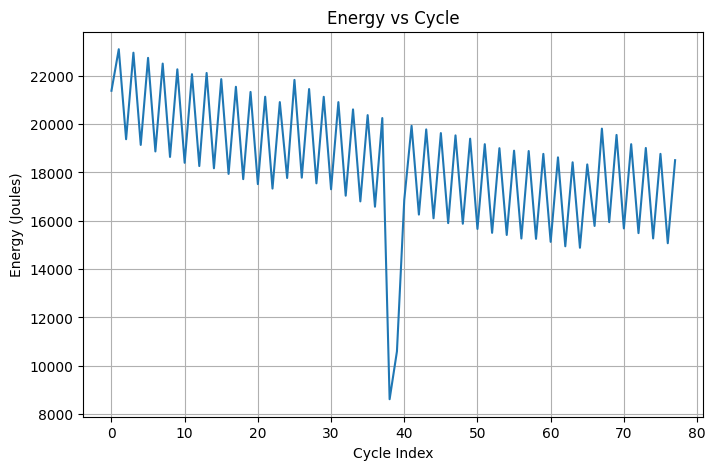

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(energy_list)

plt.xlabel("Cycle Index")
plt.ylabel("Energy (Joules)")
plt.title("Energy vs Cycle")
plt.grid()

plt.show()

In [ ]:
cycle_files = []
eis_files = []

for file in files:
    try:
        with open(os.path.join(folder_path, file), 'r') as f:
            header = f.readline()

        if "Voltage_measured" in header:
            cycle_files.append(file)
        else:
            eis_files.append(file)

    except:
        continue

print("Total cycle files:", len(cycle_files))
print("Total EIS files:", len(eis_files))

Total cycle files: 5609
Total EIS files: 1956


In [ ]:
energy_list = []

for file in cycle_files:
    try:
        df = pd.read_csv(os.path.join(folder_path, file))

        df = df.dropna().sort_values(by="Time")

        V = df["Voltage_measured"].values
        I = df["Current_measured"].values
        t = df["Time"].values

        dt = np.diff(t, prepend=t[0])

        energy = np.sum(V * I * dt)
        energy_list.append(abs(energy))

    except:
        continue

print("Total cycle files used:", len(energy_list))

Total cycle files used: 5609


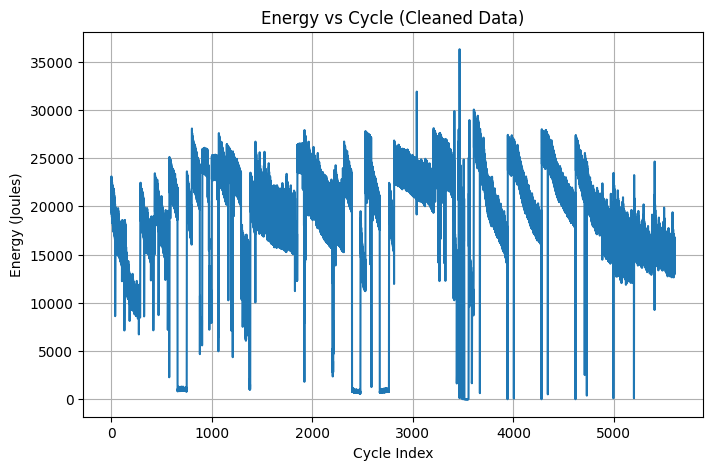

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(energy_list)

plt.xlabel("Cycle Index")
plt.ylabel("Energy (Joules)")
plt.title("Energy vs Cycle (Cleaned Data)")
plt.grid()

plt.show()

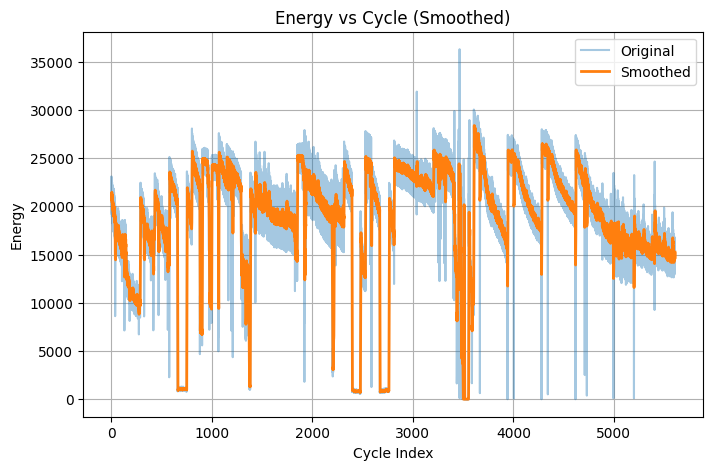

In [ ]:
import pandas as pd

smooth_energy = pd.Series(energy_list).rolling(window=5).mean()

plt.figure(figsize=(8,5))
plt.plot(energy_list, alpha=0.4, label="Original")
plt.plot(smooth_energy, linewidth=2, label="Smoothed")

plt.legend()
plt.xlabel("Cycle Index")
plt.ylabel("Energy")
plt.title("Energy vs Cycle (Smoothed)")
plt.grid()
plt.show()

In [ ]:
def compute_efficiency(file):
    df = pd.read_csv(os.path.join(folder_path, file))

    df = df.dropna().sort_values(by="Time")

    charge = df[df["Current_measured"] > 0]
    discharge = df[df["Current_measured"] < 0]

    def energy_calc(data):
        if len(data) == 0:
            return 0

        V = data["Voltage_measured"].values
        I = data["Current_measured"].values
        t = data["Time"].values

        dt = np.diff(t, prepend=t[0])
        return np.sum(V * I * dt)

    charge_energy = abs(energy_calc(charge))
    discharge_energy = abs(energy_calc(discharge))

    if charge_energy == 0:
        return np.nan

    return discharge_energy / charge_energy

In [ ]:
def find_transition_point(file):
    df = pd.read_csv(os.path.join(folder_path, file))

    df = df.dropna().sort_values(by="Time")

    V = df["Voltage_measured"].values
    t = df["Time"].values

    # slope
    dV_dt = np.gradient(V, t)

    # find point where slope changes most
    transition_idx = np.argmin(dV_dt)  # steepest drop

    return t[transition_idx]

In [ ]:
energy_list = []
efficiency_list = []
transition_list = []

for file in cycle_files:
    try:
        df = pd.read_csv(os.path.join(folder_path, file))
        df = df.dropna().sort_values(by="Time")

        # ENERGY
        V = df["Voltage_measured"].values
        I = df["Current_measured"].values
        t = df["Time"].values

        dt = np.diff(t, prepend=t[0])
        energy = abs(np.sum(V * I * dt))

        # EFFICIENCY
        eff = compute_efficiency(file)

        # TRANSITION
        trans = find_transition_point(file)

        energy_list.append(energy)
        efficiency_list.append(eff)
        transition_list.append(trans)

    except:
        continue

print("Total samples:", len(energy_list))

Total samples: 5609


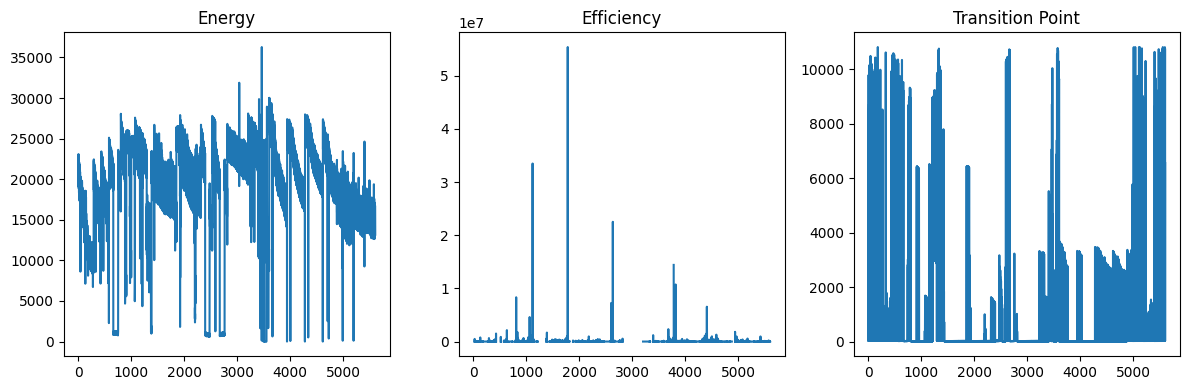

In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.plot(energy_list)
plt.title("Energy")

plt.subplot(1,3,2)
plt.plot(efficiency_list)
plt.title("Efficiency")

plt.subplot(1,3,3)
plt.plot(transition_list)
plt.title("Transition Point")

plt.tight_layout()
plt.show()

In [ ]:
def find_transition_normalized(file):
    df = pd.read_csv(os.path.join(folder_path, file))

    df = df.dropna().sort_values(by="Time")

    V = df["Voltage_measured"].values
    t = df["Time"].values

    # Smooth voltage
    V_smooth = pd.Series(V).rolling(window=10, center=True).mean()
    V_smooth = V_smooth.bfill().ffill().values

    # Compute slope
    dV_dt = np.gradient(V_smooth, t)

    # Detect strong drop region
    threshold = np.percentile(dV_dt, 5)

    indices = np.where(dV_dt < threshold)[0]

    if len(indices) == 0:
        return 0

    idx = indices[0]

    return t[idx] / t[-1]

In [ ]:
energy_list = []
transition_list = []

for file in cycle_files:
    try:
        df = pd.read_csv(os.path.join(folder_path, file))
        df = df.dropna().sort_values(by="Time")

        V = df["Voltage_measured"].values
        I = df["Current_measured"].values
        t = df["Time"].values

        dt = np.diff(t, prepend=t[0])
        energy = abs(np.sum(V * I * dt))

        trans = find_transition_normalized(file)

        energy_list.append(energy)
        transition_list.append(trans)

    except Exception as e:
      print("Error in file:", file)
      print(e)
      break

print("Total samples:", len(energy_list))

Total samples: 5609


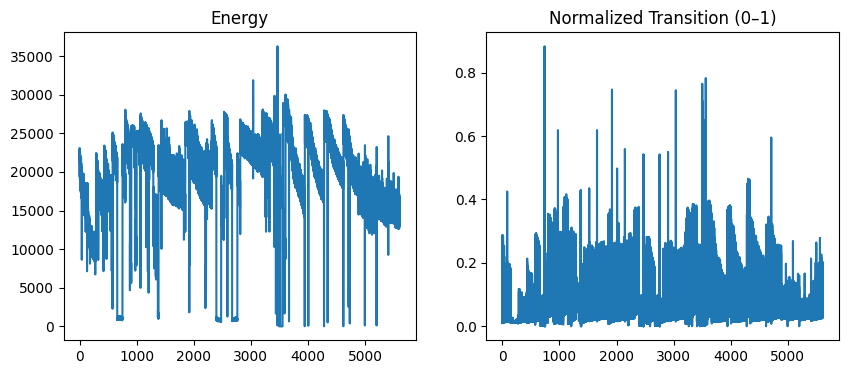

In [ ]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(energy_list)
plt.title("Energy")

plt.subplot(1,2,2)
plt.plot(transition_list)
plt.title("Normalized Transition (0–1)")

plt.show()

In [ ]:
import numpy as np

# Convert to arrays
energy_arr = np.array(energy_list)
transition_arr = np.array(transition_list)

# Input features (current cycle)
X = np.column_stack((energy_arr[:-1], transition_arr[:-1]))

# Target (next cycle energy)
y = energy_arr[1:]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (5608, 2)
y shape: (5608,)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

# Split (IMPORTANT: no shuffle for time-series)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
mae = mean_absolute_error(y_test, y_pred)
print("MAE (Error):", mae)

MAE (Error): 2547.726893633375


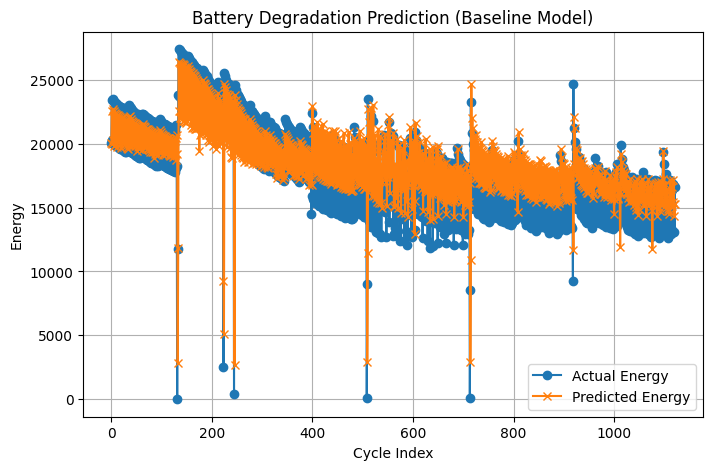

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(y_test, label="Actual Energy", marker='o')
plt.plot(y_pred, label="Predicted Energy", marker='x')

plt.xlabel("Cycle Index")
plt.ylabel("Energy")
plt.title("Battery Degradation Prediction (Baseline Model)")
plt.legend()
plt.grid()

plt.show()

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

In [ ]:
# Random Forest Model

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

# Metrics

mae = mean_absolute_error(y_test, rf_pred)

rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

r2 = r2_score(y_test, rf_pred)

print("Random Forest Results")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

Random Forest Results
MAE: 2331.691317229083
RMSE: 3486.9342365015746
R2: 0.09119731829678579


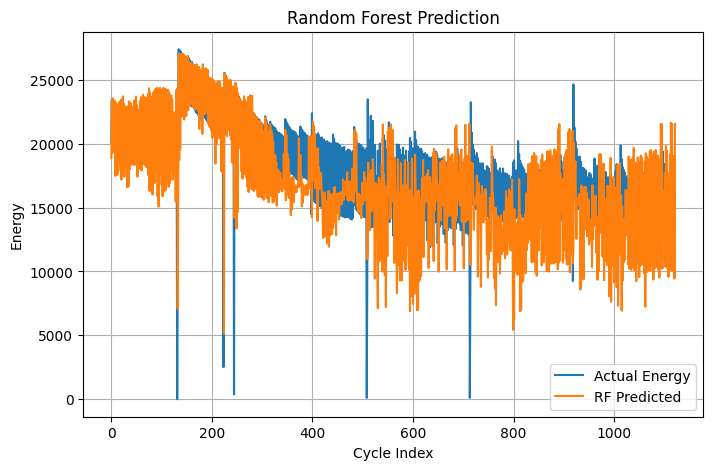

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(y_test, label='Actual Energy')

plt.plot(rf_pred, label='RF Predicted')

plt.xlabel("Cycle Index")
plt.ylabel("Energy")

plt.title("Random Forest Prediction")

plt.legend()

plt.grid()

plt.show()

In [ ]:
!pip install xgboost

In [ ]:
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

mae = mean_absolute_error(y_test, xgb_pred)

rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))

r2 = r2_score(y_test, xgb_pred)

print("XGBoost Results")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

NameError: name 'XGBRegressor' is not defined

In [ ]:
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

mae = mean_absolute_error(y_test, xgb_pred)

rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))

r2 = r2_score(y_test, xgb_pred)

print("XGBoost Results")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

NameError: name 'XGBRegressor' is not defined

In [ ]:
from xgboost import XGBRegressor

In [ ]:
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

mae = mean_absolute_error(y_test, xgb_pred)

rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))

r2 = r2_score(y_test, xgb_pred)

print("XGBoost Results")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

XGBoost Results
MAE: 1771.1677562558386
RMSE: 2610.241651662921
R2: 0.4907353661500271


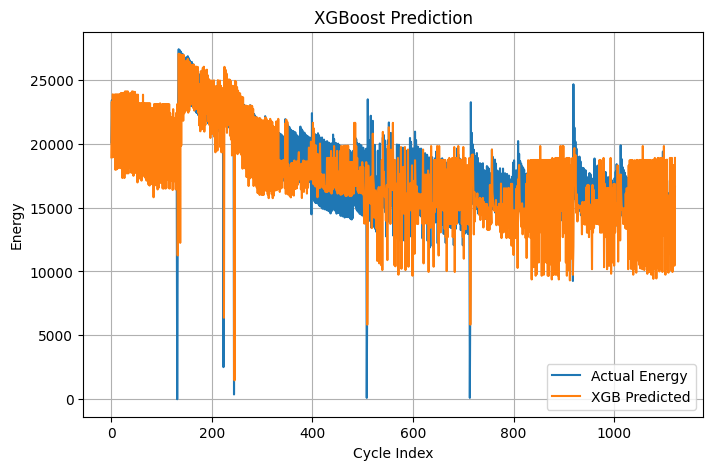

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(y_test, label='Actual Energy')

plt.plot(xgb_pred, label='XGB Predicted')

plt.xlabel("Cycle Index")
plt.ylabel("Energy")

plt.title("XGBoost Prediction")

plt.legend()

plt.grid()

plt.show()

In [ ]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

In [ ]:
scaler = MinMaxScaler()

energy_scaled = scaler.fit_transform(
    energy_arr.reshape(-1,1)
)

transition_scaled = scaler.fit_transform(
    transition_arr.reshape(-1,1)
)

In [ ]:
sequence_length = 10

X_seq = []
y_seq = []

In [ ]:
for i in range(len(energy_scaled) - sequence_length):

    energy_window = energy_scaled[
        i:i+sequence_length
    ]

    transition_window = transition_scaled[
        i:i+sequence_length
    ]

    combined = np.hstack(
        (energy_window, transition_window)
    )

    X_seq.append(combined)

    y_seq.append(
        energy_scaled[i+sequence_length]
    )

X_seq = np.array(X_seq)

y_seq = np.array(y_seq)

print(X_seq.shape)
print(y_seq.shape)

(5599, 10, 2)
(5599, 1)


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(
    X_seq,
    y_seq,
    test_size=0.2,
    shuffle=False
)

print(X_train_seq.shape)
print(X_test_seq.shape)

(4479, 10, 2)
(1120, 10, 2)


In [ ]:
import torch

In [ ]:
X_train_tensor = torch.tensor(
    X_train_seq,
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test_seq,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train_seq,
    dtype=torch.float32
)

y_test_tensor = torch.tensor(
    y_test_seq,
    dtype=torch.float32
)

In [ ]:
import torch.nn as nn

In [ ]:
class BatteryTransformer(nn.Module):

    def __init__(self):

        super().__init__()

        # Input embedding
        self.embedding = nn.Linear(2, 64)

        # Transformer Encoder Layer
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=64,
            nhead=4,
            batch_first=True
        )

        # Transformer Encoder
        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=2
        )

        # Final prediction layer
        self.fc = nn.Linear(64, 1)

    def forward(self, x):

        # Embedding
        x = self.embedding(x)

        # Transformer
        x = self.transformer(x)

        # Global average pooling
        x = x.mean(dim=1)

        # Final output
        x = self.fc(x)

        return x

In [ ]:
model = BatteryTransformer()

print(model)

BatteryTransformer(
  (embedding): Linear(in_features=2, out_features=64, bias=True)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=2048, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=2048, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


In [ ]:
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [ ]:
epochs = 50

loss_history = []

for epoch in range(epochs):

    model.train()

    optimizer.zero_grad()

    outputs = model(X_train_tensor)

    loss = criterion(
        outputs.squeeze(),
        y_train_tensor.squeeze()
    )

    loss.backward()

    optimizer.step()

    loss_history.append(loss.item())

    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.6f}")

Epoch 1/50, Loss: 0.142455
Epoch 2/50, Loss: 9.087900
Epoch 3/50, Loss: 1.925793
Epoch 4/50, Loss: 0.057186
Epoch 5/50, Loss: 0.902192
Epoch 6/50, Loss: 1.083525
Epoch 7/50, Loss: 0.665276
Epoch 8/50, Loss: 0.193393
Epoch 9/50, Loss: 0.027876
Epoch 10/50, Loss: 0.213809
Epoch 11/50, Loss: 0.356396
Epoch 12/50, Loss: 0.309018
Epoch 13/50, Loss: 0.180779
Epoch 14/50, Loss: 0.076935
Epoch 15/50, Loss: 0.033603
Epoch 16/50, Loss: 0.038950
Epoch 17/50, Loss: 0.066639
Epoch 18/50, Loss: 0.094941
Epoch 19/50, Loss: 0.109856
Epoch 20/50, Loss: 0.108351
Epoch 21/50, Loss: 0.094316
Epoch 22/50, Loss: 0.073961
Epoch 23/50, Loss: 0.053872
Epoch 24/50, Loss: 0.039606
Epoch 25/50, Loss: 0.032811
Epoch 26/50, Loss: 0.034145
Epoch 27/50, Loss: 0.040487
Epoch 28/50, Loss: 0.048280
Epoch 29/50, Loss: 0.054472
Epoch 30/50, Loss: 0.056061
Epoch 31/50, Loss: 0.053884
Epoch 32/50, Loss: 0.048915
Epoch 33/50, Loss: 0.042263
Epoch 34/50, Loss: 0.036193
Epoch 35/50, Loss: 0.032214
Epoch 36/50, Loss: 0.030573
E

In [ ]:
model.eval()

with torch.no_grad():

    transformer_pred = model(X_test_tensor)

transformer_pred = transformer_pred.numpy()

y_true = y_test_tensor.numpy()

In [ ]:
transformer_pred_real = scaler.inverse_transform(
    transformer_pred
)

y_true_real = scaler.inverse_transform(
    y_true
)

In [ ]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import numpy as np

In [ ]:
mae = mean_absolute_error(
    y_true_real,
    transformer_pred_real
)

rmse = np.sqrt(
    mean_squared_error(
        y_true_real,
        transformer_pred_real
    )
)

r2 = r2_score(
    y_true_real,
    transformer_pred_real
)

print("Transformer Results")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

Transformer Results
MAE: 0.062095947563648224
RMSE: 0.07749966754476705
R2: 0.24213582277297974


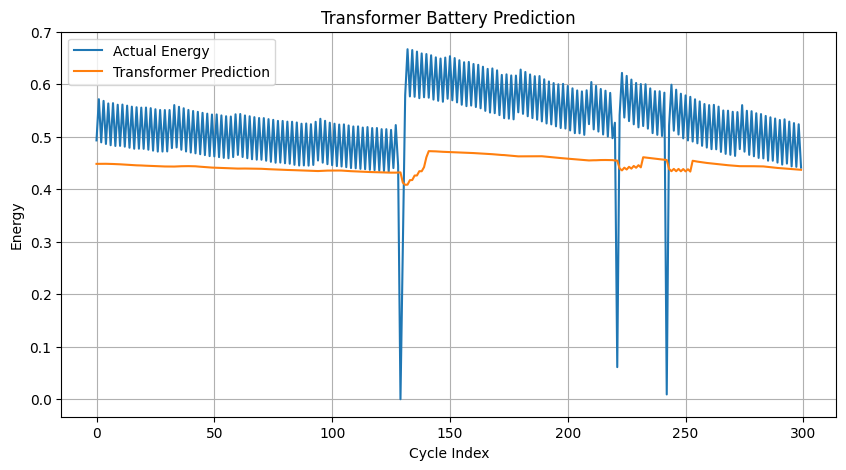

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    y_true_real[:300],
    label='Actual Energy'
)

plt.plot(
    transformer_pred_real[:300],
    label='Transformer Prediction'
)

plt.xlabel("Cycle Index")

plt.ylabel("Energy")

plt.title("Transformer Battery Prediction")

plt.legend()
ci
plt.grid()

plt.show()